In [21]:
import pickle
import os
DATASET_NAMES = ["mmlu_high_school", "mmlu_professional", "ARC-Challenge"]
ENDINGS = ["hs", "pro", "arc_challenge"]
INDEX = 2
DATASET_NAME = DATASET_NAMES[INDEX]
ENDING = ENDINGS[INDEX]

path = f"/users/astepancic/projects/apertus-probes/scratch/mera-runs/{DATASET_NAME}/Apertus-8B-Instruct-2509/df_probes_{ENDING}.pkl"
# Expand $SCRATCH environment variable if present in the path

with open(path, 'rb') as file:
    results = pickle.load(file)
results.head()


,Dataset,LLM_model,Task,Model,Inputs,Error-Type,Layer,Residuals,Coefficients,Nonzero-Features,No-Coefficients,Attempt,Model-Index,Token-Pos,y_pred,y_test,RMSE,MSE,Dummy-RMSE,Dummy-MSE
0,ARC-Challenge,swiss-ai/Apertus-8B-Instruct-2509,regression,L-0,activations,sm,0,"[0.5373373031616211, 2.067399263381958, 1.4841...","[264087.03125, 1107172.125, 60129.5, -49277.68...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",False,1,1,last,"[0.87451171875, -0.2257080078125, -0.758056640...","[1.411849, -2.2931073, -2.242179, -2.7854855, ...",3.407788,3.407788,3.799569,3.799569
1,ARC-Challenge,swiss-ai/Apertus-8B-Instruct-2509,regression,L-0,activations,sm,0,"[2.252396821975708, 0.011538684368133545, 1.18...","[-566349.8125, 184210.34375, 7916.4375, -25822...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",False,1,2,last,"[-0.5673828125, -0.79931640625, -0.5673828125,...","[-2.8197796, -0.7877777, 0.61822075, -4.034644...",3.553476,3.553476,3.905666,3.905666
2,ARC-Challenge,swiss-ai/Apertus-8B-Instruct-2509,regression,L-0,activations,sm,0,"[2.1321232318878174, 1.1560888290405273, 0.057...","[-63574.80078125, -744739.25, 762883.375, 5392...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",False,1,3,last,"[1.342529296875, -0.88232421875, -0.8823242187...","[3.4746525, -2.038413, -0.93950546, -4.211522,...",3.527624,3.527624,3.822455,3.822455
3,ARC-Challenge,swiss-ai/Apertus-8B-Instruct-2509,regression,L-0,activations,sm,0,"[1.808959722518921, 1.6870168447494507, 2.8346...","[828208.5, -450487.6875, -324363.71875, -31187...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",False,1,4,last,"[-1.0390625, -1.0390625, -0.820068359375, -1.0...","[-2.8480222, 0.64795434, 2.014576, -2.8803816,...",3.432724,3.432724,3.876726,3.876726
4,ARC-Challenge,swiss-ai/Apertus-8B-Instruct-2509,regression,L-0,activations,sm,0,"[3.398202657699585, 1.4278042316436768, 2.9031...","[226317.6875, -1751997.25, 991694.6875, 103035...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",False,1,5,last,"[-0.6005859375, -0.6005859375, -0.222534179687...","[2.7976167, -2.0283902, 2.6806655, 3.6745973, ...",3.899157,3.899157,4.256005,4.256005


Plot saved to rmse_comparison_arc_challenge_exact.png


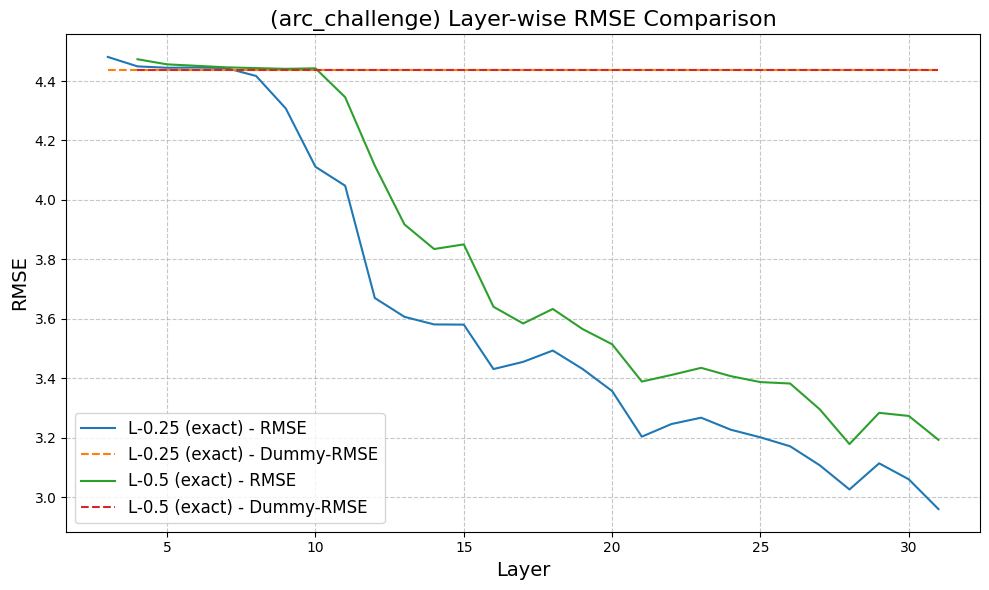

Plot saved to rmse_comparison_arc_challenge_last.png


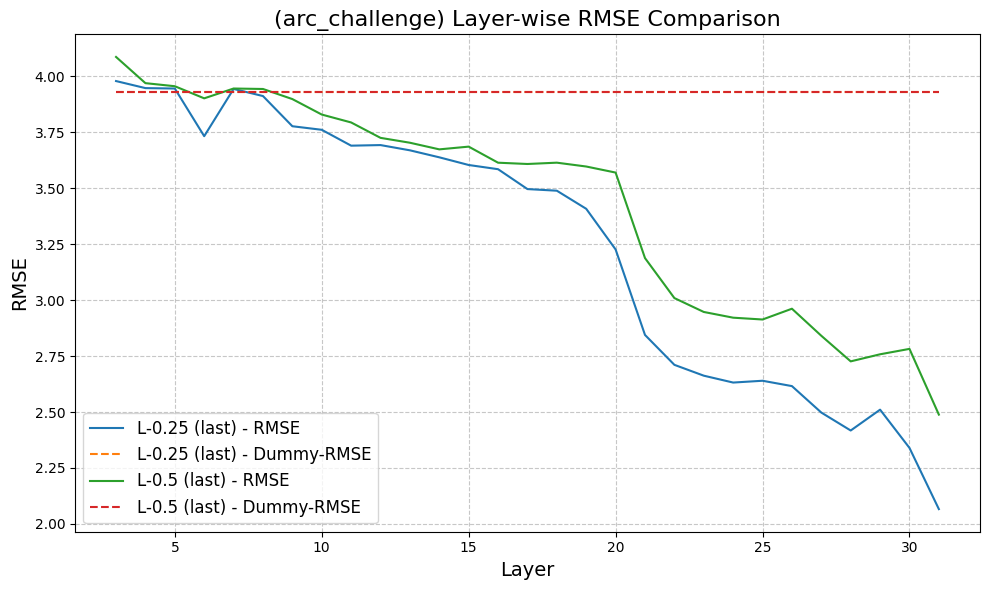

In [22]:
import matplotlib.pyplot as plt

# Define a function to plot RMSE for multiple models or token positions in one figure
def plot_rmse_comparison(grouped_data, models_to_plot, token_positions, save_path=None):
    plt.figure(figsize=(10, 6))

    for model in models_to_plot:
        for token_pos in token_positions:
            # Filter data for the specific model and token position
            group = grouped_data[(grouped_data['Model'] == model) & (grouped_data['Token-Pos'] == token_pos)]
            
            # Group by 'Layer' and calculate the mean RMSE
            layer_averages = group.groupby('Layer')[['RMSE', "Dummy-RMSE"]].mean()
            # Plot RMSE for the current model and token position
            plt.plot(
                layer_averages.index,
                layer_averages['RMSE'],
                label=f'{model} ({token_pos}) - RMSE'
            )
            
            # Plot Dummy-RMSE for the current model and token position
            plt.plot(
                layer_averages.index,
                layer_averages['Dummy-RMSE'],
                linestyle='--',  # Dashed line for Dummy-RMSE
                label=f'{model} ({token_pos}) - Dummy-RMSE'
            )

    # Add labels, title, and legend
    plt.title(f'({ENDING}) Layer-wise RMSE Comparison', fontsize=16)
    plt.xlabel('Layer', fontsize=14)
    plt.ylabel('RMSE', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()

    # Save the plot if a save path is provided
    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"Plot saved to {save_path}")

    plt.show()

# Example usage
models_to_plot = ['L-0.25', 'L-0.5']
token_positions = ['exact'] # Replace with actual token positions
save_path = f"rmse_comparison_{ENDING}"
plot_rmse_comparison(results, models_to_plot, token_positions, save_path=save_path +'_exact.png')
token_positions = ['last']
plot_rmse_comparison(results, models_to_plot, token_positions, save_path=save_path + '_last.png')
